# Regression
# 분류와 회귀의 가장 큰 차이점은 label이 continuous인가 discontinuous한가이다.

Here's a summary for regression
1. Univariate Linear Regression
2. Gradient Descent 
3. Multivariate Linear Regression
4. Polynomial Regression

## Univariate Linear Regression

회귀분석에서 주 목적은 변수들의 관계를 찾는데 있다. 일변량 선형 회귀분석은 하나의 독립변수(입력값)와 종속변수(출력값)의 관계를 찾는데 집중한다. 
Linear regression (Univariet) uses one independent variable to explain or predict the outcome of the dependent variable Y

Assume we have $(x_i, y_i),~   i \in \{1..N\}$. (here $x_i$ is independent variable, $y_i$ is dependent variable.) 

linear regression assumes there's linear correlation between two variables. (The simplest model :) ) 
In linear regression, we can have : 


$y_i = m x_i + n + \epsilon_i $

m is slope or gradient 
n is intercept or bias 
$\epsilon$ is error (or noise)이며, $m$ $n$ are constants. 

How can we 'guess'  $m$ and $n$? 
In a meaningful way? 

- Our goal is to minimize the error 
- The error is the different between our prediction and actual value: $\hat{y}_i= m x_i + n$  vs $y_i$
- For ease of computation, we minimize the sum of square error (might want to read: root-mean square, Gaussian noise) 


Let's try to minimize the equation below : 

\begin{align}
E(m,n) &= \sum \epsilon_i^2\\
        & = \sum (y_i - \hat{y}_i )^2 \\
       & = \sum (y_i - m x_i - n )^2
\end{align}

최소자승법(OLS)에 따라 위 수식을 최소화 하는 $m$과 $n$값은 $m$과 $n$에 대해 미분하여 그 값이 0이 되는 값임을 알고 있다. 위 함수를 각각 $m$과 $n$에 대해 편미분해보자.  

\begin{align}
\partial E(m,n) \over \partial m &= -2   \sum (y_i - m x_i - n )x_i\\
\partial E(m,n) \over \partial n & = -2  \sum (y_i - m x_i - n ) \\
\end{align}

위 두 식이 0이 되게 만드는 $m$과 $n$을 찾으면 된다. (참 간단하다...) 

먼저 n에 대하여 방정식을 풀면, 
- $n = \sum(y_i - m x_i) / N$ 또는 $\bar{y} - m\bar{x}$
- $m = {\sum (y_i - \bar{y} )(x_i - \bar{x}) \over \sum (x_i - \bar{x} )(x_i - \bar{x})} $ 또는 $Cov(x,y)\over Var(x)$


### 실습

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

In [5]:
df = pd.read_csv("SalaryData.csv")
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [6]:
df['YearsExperience']

0      1.1
1      1.3
2      1.5
3      2.0
4      2.2
5      2.9
6      3.0
7      3.2
8      3.2
9      3.7
10     3.9
11     4.0
12     4.0
13     4.1
14     4.5
15     4.9
16     5.1
17     5.3
18     5.9
19     6.0
20     6.8
21     7.1
22     7.9
23     8.2
24     8.7
25     9.0
26     9.5
27     9.6
28    10.3
29    10.5
Name: YearsExperience, dtype: float64

In [7]:
# scikit-learn의 LinearRegression 모델은 학습 데이터로 2차원 배열(Matrix) 형식을 기대
# 현재 df["YearsExperience"]를 np.array()로 변환하면 1차원 배열(Vector)이 되어 발생하는 오류
lin_reg = LinearRegression()

lin_reg.fit(np.array(df["YearsExperience"]), np.array(df["Salary"]))

ValueError: Expected 2D array, got 1D array instead:
array=[ 1.1  1.3  1.5  2.   2.2  2.9  3.   3.2  3.2  3.7  3.9  4.   4.   4.1
  4.5  4.9  5.1  5.3  5.9  6.   6.8  7.1  7.9  8.2  8.7  9.   9.5  9.6
 10.3 10.5].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [8]:
lin_reg = LinearRegression()
#.fit(훈련 데이터,타겟 데이터)
lin_reg.fit(np.array(df["YearsExperience"]).reshape(-1,1), np.array(df["Salary"]))

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Let's stop for a sec....,what is reshape?

In [9]:
np.array(df["YearsExperience"]).reshape(-1,1)

array([[ 1.1],
       [ 1.3],
       [ 1.5],
       [ 2. ],
       [ 2.2],
       [ 2.9],
       [ 3. ],
       [ 3.2],
       [ 3.2],
       [ 3.7],
       [ 3.9],
       [ 4. ],
       [ 4. ],
       [ 4.1],
       [ 4.5],
       [ 4.9],
       [ 5.1],
       [ 5.3],
       [ 5.9],
       [ 6. ],
       [ 6.8],
       [ 7.1],
       [ 7.9],
       [ 8.2],
       [ 8.7],
       [ 9. ],
       [ 9.5],
       [ 9.6],
       [10.3],
       [10.5]])

In [10]:
print("Coefficients: ", lin_reg.coef_)
print("Intercept: ", lin_reg.intercept_)
# 예측하기: lin_reg.predict([[5]]) → 경력이 5년일 때 예상 연봉은?
# 기울기 확인: lin_reg.coef_ → 경력이 1년 오를 때 연봉은 평균적으로 얼마만큼 오르는가?
# 절편 확인: lin_reg.intercept_ → 경력이 0년(신입)일 때의 기본 연봉은 얼마인가?

Coefficients:  [9449.96232146]
Intercept:  25792.20019866871


자 그렇다면, 오늘 배운 내용을 바탕으로 직접 구해보자.

아래의 힌트를 사용하자. (시간을 절약하기위해...)

In [11]:
df['YearsExperience'].var()
# 경력(YearsExperience)' 데이터가 평균으로부터 얼마나 멀리 퍼져 있는지, 분산
# 각 데이터에서 평균을 뺀 값의 제곱을 모두 더해 데이터 개수(n-1)로 나눈 값

np.float64(8.053609195402299)

In [12]:
df.cov()
# 공분산 행렬 (Covariance Matrix)
# 양수 (+): 한 변수가 증가할 때 다른 변수도 같이 증가하는 경향 (정비례 관계)
# 음수 (-): 한 변수가 증가할 때 다른 변수는 감소하는 경향 (반비례 관계)
# 0에 가까움: 두 변수 사이에 아무런 선형적 관계가 없음
# 예를 들어, YearsExperience와 Salary 사이의 공분산 값이 큰 양수라면 "경력이 쌓일수록 연봉도 높아진다"는 흐름을 수치로 확인할 수 있습니다.

,YearsExperience,Salary
YearsExperience,8.053609,7.610630e+04
Salary,76106.303448,7.515510e+08


## Gradient Descent

선형회귀에서 OLS(Ordinary Least Squares,최소제곱법)가 불가능하거나,   
OLS의 연산의 실행속도가 느리다면, 다른 방법으로 독립변수와 종속변수의 관계를 찾아야 한다.

이때, 사용하는 것이 Gradient Descent 이며, Gradient Descent 의 알고리즘은 다음과 같다.

### Gradient Descent Updates

repeat until convergence: 
    $\theta_j := \theta_j - \alpha {\partial \over \partial \theta_j}  J(\theta_0, \theta_1)  $


여기서 J는 지난주 수식의 E(m,n)으로 생각하고, $\theta_1$ 와 $\theta_0$을 각각 $m$,$n$이라고 가정하자. 

또한 $\alpha$는 learning rate라고도 하며, 얼마나 모델을 빨리 학습하는지를 좌우 한다. 

이제 GD를 이용하여, 의미있는 m과 n을 구해보도록 하자. 

먼저 cost function J(또는 E)를 정의하자.

In [13]:
def compute_cost(n,m, points): # 평균 제곱 오차 구하기
    total_cost = 0
    N = float(len(points))      # 왜 float로 casting 했는지 ? 
    
    for i in range(len(points)):
        x = points[i,0]
        y = points[i,1]
        total_cost += (y-(m*x+n))**2
        
    return total_cost/N    # 때에 따라 N은 없어도 됨.

다음으로 Gradient Descent 함수를 정의하자. 

In [14]:
def gradient_descent_runner(points, starting_m, starting_n, learning_rate, num_iterations):
    
    m = starting_m
    n = starting_n
    
    cost_graph = []
    
    for i in range(num_iterations):
        cost_graph.append(compute_cost(n,m,points))
        m,n = step_gradient(m,n, points, learning_rate)
        
    return [m,n,cost_graph]


def step_gradient(m_current, n_current, points, learning_rate):
    m_gradient = 0 
    n_gradient = 0 
    N = float(len(points))
    
    for i in range(len(points)):
        x = points[i,0]
        y = points[i,1]
        m_gradient += -(2/N)*x*(y-(m_current*x + n_current))
        n_gradient += -(2/N)*(y-(m_current*x + n_current))
        
    m_updated = m_current - learning_rate * m_gradient 
    n_updated = n_current - learning_rate * n_gradient 
        
    return m_updated, n_updated
        

In [15]:
learning_rate = 0.01
initial_n = 10
initial_m = 10
num_iterations = 1000

points = np.array(df)
m, n , cost_graph = gradient_descent_runner(points, initial_m, initial_n, learning_rate, num_iterations)

In [16]:
n

np.float64(25448.30186450865)

In [17]:
m

np.float64(9500.995394487247)

In [18]:
cost_graph

[np.float64(6491892001.066667),
 np.float64(594623671.9306129),
 np.float64(182970237.86586666),
 np.float64(153352433.68934792),
 np.float64(150348257.2462904),
 np.float64(149205448.5546816),
 np.float64(148200151.04344863),
 np.float64(147212245.85999086),
 np.float64(146233301.7339719),
 np.float64(145262666.06525564),
 np.float64(144300228.5259652),
 np.float64(143345917.10076806),
 np.float64(142399662.98563942),
 np.float64(141461398.1387671),
 np.float64(140531055.10544455),
 np.float64(139608567.00136802),
 np.float64(138693867.50700223),
 np.float64(137786890.86275494),
 np.float64(136887571.8642455),
 np.float64(135995845.85761696),
 np.float64(135111648.73488778),
 np.float64(134234916.9293433),
 np.float64(133365587.41096526),
 np.float64(132503597.68190084),
 np.float64(131648885.77196972),
 np.float64(130801390.23420839),
 np.float64(129961050.140453),
 np.float64(129127805.07695895),
 np.float64(128301595.14005786),
 np.float64(127482360.93185058),
 np.float64(126670043

In [19]:
points[0,0]

np.float64(1.1)

In [20]:
len(points)

30

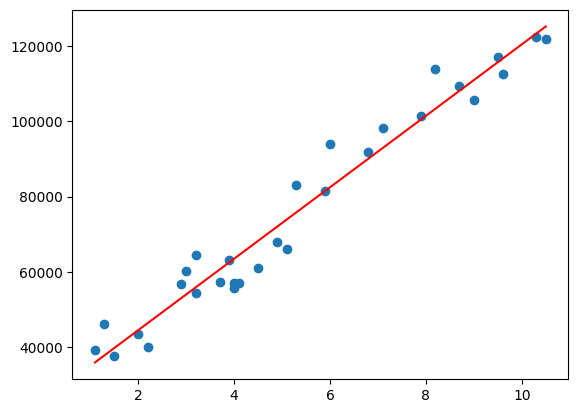

In [21]:
%matplotlib inline 
import matplotlib.pyplot as plt
x = np.array(points[:,0])
y = np.array(points[:,1])
plt.scatter(x,y)
pred = m*x + n 
plt.plot(x,pred, c='r')
plt.show()

## Sample  이거 연습 많이하자!!

아래와 같이 hyper parameter 와 initial point를 지정하여, GD를 통해 m과 n을 최적화 한다고 하자.

In [22]:
learning_rate = 0.01     # hyper parameter: alpha
num_iterations = 1000     # hyper parameter: number of steps 
initial_m = 10      # initial guess for m 
initial_n = 4000      # initial guess for n 

GD를 1000번 수행하며, m과 n이 중간에 생긴다. 
이 값들을 자 저장하여, 그래프를 1000번 그리면 너무 많으니, 100 번째, 200번째, 300번째.... 10000 번째 의 10개의 m과 n을 각각 구해 위와 같이 그래프로 그리시오. 



(조건: 그래프의 색깔은 100번째부터 10000번째로 상승하면서, 그래프의 색깔이 진하도록 조절하시오! ) 